In [1]:
import matplotlib.pyplot as plt
import importlib

import msm_system_construction
import msm_systems
import unbiased_simulation_analysis
import numpy as np

12.5
implied timescale converged to within 5.0% of the value calculated for 200 bins at 53 bins


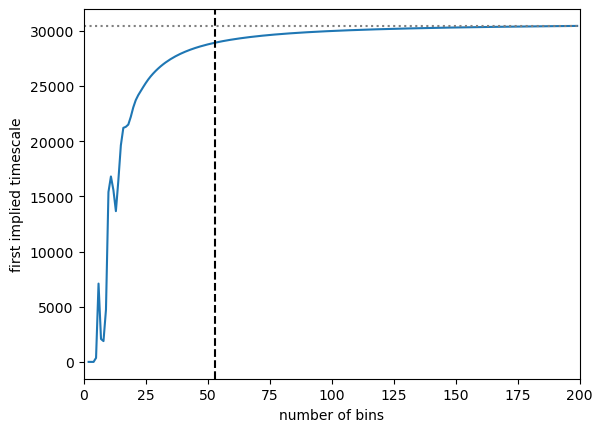

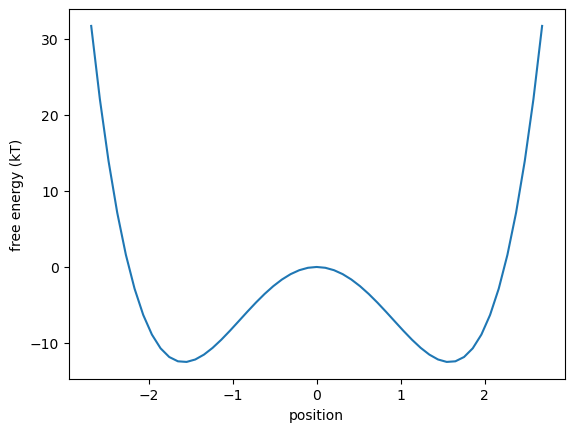

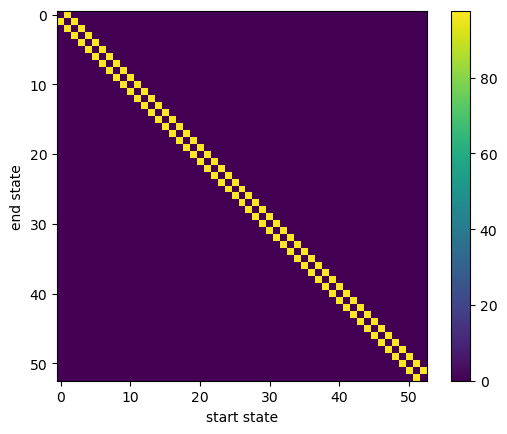

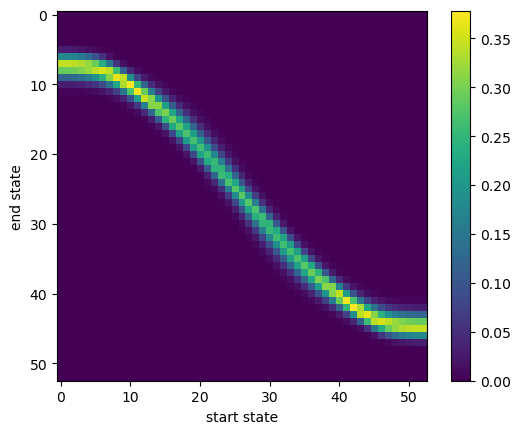

In [4]:
importlib.reload(msm_systems)
importlib.reload(msm_system_construction)

A = 2
B = 5
D = 1
dw1 = msm_systems.double_well(A, B, D)
print(dw1.depth())

kT = 1
lag_time = 0.01

min_bins = msm_system_construction.timescale_vs_spatial_discretization(dw1, kT, lag_time, (2,200), tolerance=0.05)

g_eq, prefactors, xb = msm_system_construction.spatially_discretize_linear_system(dw1, min_bins)

plt.plot(xb, g_eq)
plt.xlabel("position")
plt.ylabel("free energy (kT)")
plt.show()

plt.imshow(prefactors)
plt.colorbar()
plt.xlabel("start state")
plt.ylabel("end state")
plt.show()

tpm = msm_system_construction.energies_and_prefactors_to_tpm(g_eq, prefactors, kT, lag_time)
plt.imshow(tpm)
plt.colorbar()
plt.xlabel("start state")
plt.ylabel("end state")
plt.show()

In [11]:
importlib.reload(unbiased_simulation_analysis)

unbiased_simulation_analysis.unbiased_simulation_to_mtd_params(tpm, min_bins, init_state=np.argmin(g_eq), lag_time=lag_time, n_steps=-1)

running for 28922 steps
Estimated whole-system diffusive timescale: 80.63193571433513 frame save intervals
Estimated barrier from MFPT and diffusion in initial state:  10.487653838203029  kT


(1.624344746934569, 0.1, 0.030433469260988836, 19.975307676406057)